# GLMM to evaluate the factors that impact Relative Error and Variability

# Packages

In [2]:
packages <- list("lme4", "glmmTMB", "ggeffects")
for (pack in packages) {
    if (!requireNamespace(pack, quietly = TRUE)) {
      print(paste('Installing', pack))
      install.packages(pack, type = "source")
    }
}

In [2]:
library(readr)
library(lme4)
library(glmmTMB)
library(ggplot2)
library(ggeffects)

Loading required package: Matrix



# Read Dataset

In [8]:
ds_suited_v0 = read_csv("data/dataset/suited_dataset.csv", show_col_types = FALSE)
head(ds_suited_v0)

farm,animal_id,weight,woolLevel,score,captured_at_as_min,depth,unexpected_behavior,gender
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<dbl>
Farm A,021IK4BJ2GltxzphIRtY,42.2,0,4,547,0200_15565_2025_01_26_09_07_57_912318_DEPTH_320_240_1.png,FALSE,1
Farm A,021IK4BJ2GltxzphIRtY,42.2,0,4,547,0200_15566_2025_01_26_09_07_58_014755_DEPTH_320_240_1.png,FALSE,1
Farm A,021IK4BJ2GltxzphIRtY,42.2,0,4,547,0200_15567_2025_01_26_09_07_58_123809_DEPTH_320_240_1.png,FALSE,1
Farm A,021IK4BJ2GltxzphIRtY,42.2,0,4,547,0200_15569_2025_01_26_09_07_58_344763_DEPTH_320_240_1.png,FALSE,1
Farm A,021IK4BJ2GltxzphIRtY,42.2,0,4,547,0200_15568_2025_01_26_09_07_58_235040_DEPTH_320_240_1.png,FALSE,1
Farm A,021IK4BJ2GltxzphIRtY,42.2,0,4,547,0200_15570_2025_01_26_09_07_58_448220_DEPTH_320_240_1.png,FALSE,1


In [9]:
dataset_v0 = read_csv("data/dataset/ds_test_set_with_metrics.csv", show_col_types = FALSE)
dim(dataset_v0)

[1] 2084   24

In [34]:
dataset_v1 = merge(x = dataset_v0, y = ds_suited_v0[,c('depth','unexpected_behavior')], by='depth')
dim(dataset_v1)

[1] 2084   25

In [35]:
dataset_v1 = dataset_v1[,c('farm','animal_id','weight','train_size','mape','vi','qi','qi_train','qtt_in_train','farms','w_cv','unexpected_behavior')]
colnames(dataset_v1)

[1] "farm"                "animal_id"           "weight"             
 [4] "train_size"          "mape"                "vi"                 
 [7] "qi"                  "qi_train"            "qtt_in_train"       
[10] "farms"               "w_cv"                "unexpected_behavior"

In [36]:
dataset_v1$animal_id = as.factor(dataset_v1$animal_id)
dataset_v1$farm  = as.factor(dataset_v1$farm)
dataset_v1$unexpected_behavior = as.factor(dataset_v1$unexpected_behavior)

head(dataset_v1)

,farm,animal_id,weight,train_size,mape,vi,qi,qi_train,qtt_in_train,farms,w_cv,unexpected_behavior
,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,Farm A,C6q3et9Ucor3cQ6B5xm5,0.5125945,0.6648045,0.09887677,2.021462,0.6649920,0.0000000,0.4871407,1,0.05804269,FALSE
2,Farm A,C6q3et9Ucor3cQ6B5xm5,0.5125945,0.9245810,0.05778653,7.450662,0.6649920,0.3048438,0.6459909,2,0.23088900,FALSE
3,Farm A,C6q3et9Ucor3cQ6B5xm5,0.5125945,0.9245810,0.07278873,7.450662,0.6662251,0.3048438,0.6459909,2,0.23088900,FALSE
4,Farm A,C6q3et9Ucor3cQ6B5xm5,0.5125945,0.6648045,0.10411542,2.021462,0.6662251,0.0000000,0.4871407,1,0.05804269,FALSE
5,Farm A,C6q3et9Ucor3cQ6B5xm5,0.5125945,0.6648045,0.09155772,2.021462,0.6729508,0.0000000,0.4871407,1,0.05804269,FALSE
6,Farm A,C6q3et9Ucor3cQ6B5xm5,0.5125945,0.9245810,0.18969618,7.450662,0.6729508,0.3048438,0.6459909,2,0.23088900,FALSE


In [37]:
# Function to normalize a numeric vector to a 0-1 range
normalize <- function(x) {
  ((x - min(x, na.rm = TRUE)) / (max(x, na.rm = TRUE) - min(x, na.rm = TRUE))) + 0.0001
}

In [38]:
dataset_v1$weight <- normalize(dataset_v1$weight)
dataset_v1$train_size <- normalize(dataset_v1$train_size)
dataset_v1$qi <- normalize(dataset_v1$qi)
dataset_v1$qi_train <- normalize(dataset_v1$qi_train)
dataset_v1$qtt_in_train <- normalize(dataset_v1$qtt_in_train)
dataset_v1$w_cv <- normalize(dataset_v1$w_cv)

# 1. Prediction Error Analysis

## Data Distribution
Analyze relative error distribution

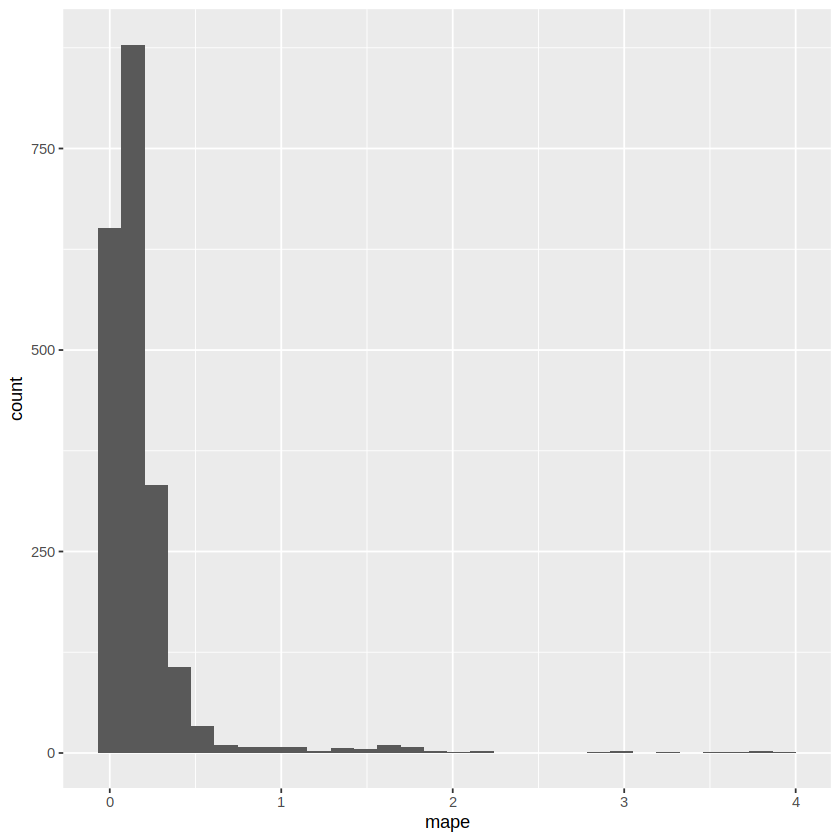

In [12]:
ggplot(dataset_v0, aes(x = mape)) + geom_histogram(bins = 30)

## Candidate Model #1

### Adjust Models

#### Base Model

In [13]:
modelA_1 <- lme4::glmer(
  "mape ~ train_size + qi_train + qtt_in_train + qi + weight + (1|animal_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_1)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size + qi_train + qtt_in_train + qi + weight + (1 |  
    animal_id)
   Data: dataset_v0

      AIC       BIC    logLik -2*log(L)  df.resid 
  -4058.8   -4014.1    2037.4   -4074.8      1976 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4705 -0.6801 -0.0737  0.5105  6.7036 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.4587   0.6773  
Number of obs: 1984, groups:  animal_id, 146

Fixed effects:
             Estimate Std. Error t value Pr(>|z|)    
(Intercept)   -0.9094     0.1787  -5.090 3.59e-07 ***
train_size    -0.4241     0.1303  -3.256  0.00113 ** 
qi_train      -0.5941     0.1099  -5.405 6.47e-08 ***
qtt_in_train  -0.2622     0.1749  -1.499  0.13388    
qi             0.5564     0.2104   2.644  0.00819 ** 
weight        -2.2872     0.3389  -6.749 1.49e-11 ***
---
Signif. codes:  0 ‘***’ 

#### 2-interactions

In [9]:
modelA_2 <- lme4::glmer(
  "mape ~ train_size * qi_train + qtt_in_train + qi + weight + (1|animal_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_2)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size * qi_train + qtt_in_train + qi + weight + (1 |  
    animal_id)
   Data: dataset_v0

      AIC       BIC    logLik -2*log(L)  df.resid 
  -4074.0   -4023.7    2046.0   -4092.0      1975 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4676 -0.6798 -0.0927  0.4911  6.7475 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.444    0.6664  
Number of obs: 1984, groups:  animal_id, 146

Fixed effects:
                    Estimate Std. Error t value Pr(>|z|)    
(Intercept)          -2.0133     0.3177  -6.337 2.34e-10 ***
train_size            1.5369     0.4888   3.144  0.00167 ** 
qi_train              0.7645     0.3449   2.216  0.02666 *  
qtt_in_train         -0.2944     0.1735  -1.697  0.08978 .  
qi                    0.3488     0.2108   1.654  0.09805 .  
weight               -2.3176     0.3340 

In [18]:
modelA_3 <- lme4::glmer(
  "mape ~ train_size * qtt_in_train + qi_train + qi + weight + (1|animal_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_3)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size * qtt_in_train + qi_train + qi + weight + (1 |  
    animal_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
 -4058.8  -4008.4   2038.4  -4076.8     1975 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4706 -0.6808 -0.0706  0.5073  6.6903 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.2124   0.4609  
 Residual              0.4621   0.6798  
Number of obs: 1984, groups:  animal_id, 146

Fixed effects:
                        Estimate Std. Error t value Pr(>|z|)    
(Intercept)              -1.1243     0.2361  -4.761 1.92e-06 ***
train_size               -0.2095     0.2021  -1.036 0.300115    
qtt_in_train              0.2899     0.4348   0.667 0.504919    
qi_train                 -0.4889     0.1333  -3.667 0.000245 ***
qi                        0.5446     0.2108   2.58

In [39]:
modelA_4 <- lme4::glmer(
  "mape ~ train_size * qi + qi_train + qtt_in_train + weight + (1|animal_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_4)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0048611 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size * qi + qi_train + qtt_in_train + weight + (1 |  
    animal_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
 -4062.6  -4012.3   2040.3  -4080.6     1975 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4677 -0.6854 -0.0953  0.5127  6.7262 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.2126   0.4611  
 Residual              0.4639   0.6811  
Number of obs: 1984, groups:  animal_id, 146

Fixed effects:
              Estimate Std. Error t value Pr(>|z|)    
(Intercept)   -1.24764    0.22711  -5.493 3.94e-08 ***
train_size     0.05097    0.23648   0.216 0.829361    
qi             1.48520    0.44161   3.363 0.000771 ***
qi_train      -0.70873    0.12024  -5.894 3.76e-09 ***
qtt_in_train  -0.32202    0.17680  -1.821 0.068553 .  
weight        -2.28476    0.33867  -6.746 1.5

In [20]:
modelA_5 <- lme4::glmer(
  "mape ~ train_size * weight + qi_train + qtt_in_train + qi + (1|animal_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_5)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size * weight + qi_train + qtt_in_train + qi + (1 |  
    animal_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
 -4058.4  -4008.0   2038.2  -4076.4     1975 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4715 -0.6820 -0.0728  0.5100  6.6971 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.2118   0.4602  
 Residual              0.4615   0.6793  
Number of obs: 1984, groups:  animal_id, 146

Fixed effects:
                  Estimate Std. Error t value Pr(>|z|)    
(Intercept)        -0.7468     0.2226  -3.355 0.000794 ***
train_size         -0.6769     0.2433  -2.782 0.005397 ** 
weight             -2.8449     0.5652  -5.033 4.82e-07 ***
qi_train           -0.5548     0.1144  -4.848 1.25e-06 ***
qtt_in_train       -0.2228     0.1777  -1.254 0.209900    
qi                  0

In [21]:
modelA_6 <- lme4::glmer(
  "mape ~ train_size + qi_train * qtt_in_train + qi + weight + (1|animal_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_6)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size + qi_train * qtt_in_train + qi + weight + (1 |  
    animal_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
 -4066.6  -4016.3   2042.3  -4084.6     1975 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4701 -0.6860 -0.0787  0.4810  6.6897 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.2102   0.4585  
 Residual              0.4624   0.6800  
Number of obs: 1984, groups:  animal_id, 146

Fixed effects:
                      Estimate Std. Error t value Pr(>|z|)    
(Intercept)           -1.19252    0.19887  -5.997 2.02e-09 ***
train_size            -0.20533    0.14770  -1.390  0.16448    
qi_train              -0.02102    0.21285  -0.099  0.92135    
qtt_in_train           0.07858    0.20570   0.382  0.70246    
qi                     0.47888    0.21041   2.276  0.02285 *

In [22]:
modelA_7 <- lme4::glmer(
  "mape ~ train_size + qi_train * qi + qtt_in_train + weight + (1|animal_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_7)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size + qi_train * qi + qtt_in_train + weight + (1 |  
    animal_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
 -4066.5  -4016.2   2042.3  -4084.5     1975 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4693 -0.6848 -0.0910  0.5210  6.7395 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.2177   0.4666  
 Residual              0.4629   0.6804  
Number of obs: 1984, groups:  animal_id, 146

Fixed effects:
             Estimate Std. Error t value Pr(>|z|)    
(Intercept)   -0.9464     0.1801  -5.254 1.49e-07 ***
train_size    -0.6070     0.1435  -4.231 2.33e-05 ***
qi_train       0.3923     0.3354   1.170 0.242185    
qi             0.9263     0.2457   3.771 0.000163 ***
qtt_in_train  -0.3397     0.1780  -1.909 0.056286 .  
weight        -2.2645     0.3425  -6.612 3.78e-11 *

In [23]:
modelA_8 <- lme4::glmer(
  "mape ~ train_size + qi_train * weight + qtt_in_train + qi + (1|animal_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_8)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size + qi_train * weight + qtt_in_train + qi + (1 |  
    animal_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
 -4061.3  -4011.0   2039.6  -4079.3     1975 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4695 -0.6818 -0.0675  0.4946  6.6902 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.2072   0.4552  
 Residual              0.4628   0.6803  
Number of obs: 1984, groups:  animal_id, 146

Fixed effects:
                Estimate Std. Error t value Pr(>|z|)    
(Intercept)      -0.8308     0.1817  -4.573 4.81e-06 ***
train_size       -0.3129     0.1405  -2.227   0.0260 *  
qi_train         -1.0816     0.2546  -4.248 2.15e-05 ***
weight           -2.5890     0.3644  -7.105 1.20e-12 ***
qtt_in_train     -0.3775     0.1829  -2.064   0.0390 *  
qi                0.5463     0.20

In [25]:
modelA_9 <- lme4::glmer(
  "mape ~ train_size + qi_train + qtt_in_train * qi + weight + (1|animal_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_9)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size + qi_train + qtt_in_train * qi + weight + (1 |  
    animal_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
 -4060.7  -4010.4   2039.4  -4078.7     1975 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4708 -0.6874 -0.0829  0.5137  6.6971 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.2165   0.4653  
 Residual              0.4620   0.6797  
Number of obs: 1984, groups:  animal_id, 146

Fixed effects:
                Estimate Std. Error t value Pr(>|z|)    
(Intercept)      -1.1000     0.2038  -5.398 6.74e-08 ***
train_size       -0.4266     0.1305  -3.270  0.00108 ** 
qi_train         -0.6581     0.1148  -5.731 1.00e-08 ***
qtt_in_train      0.1331     0.2670   0.498  0.61829    
qi                1.1457     0.3662   3.128  0.00176 ** 
weight           -2.3361     0.34

In [26]:
modelA_10 <- lme4::glmer(
  "mape ~ train_size + qi_train + qtt_in_train * weight + qi + (1|animal_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_10)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size + qi_train + qtt_in_train * weight + qi + (1 |  
    animal_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
 -4057.3  -4006.9   2037.6  -4075.3     1975 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4700 -0.6849 -0.0780  0.5081  6.7008 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.2113   0.4597  
 Residual              0.4625   0.6800  
Number of obs: 1984, groups:  animal_id, 146

Fixed effects:
                    Estimate Std. Error t value Pr(>|z|)    
(Intercept)          -0.9940     0.2215  -4.488 7.19e-06 ***
train_size           -0.4138     0.1313  -3.151  0.00163 ** 
qi_train             -0.5905     0.1101  -5.361 8.27e-08 ***
qtt_in_train         -0.1217     0.2797  -0.435  0.66357    
weight               -1.9653     0.6049  -3.249  0.00116 ** 
qi       

In [27]:
modelA_11 <- lme4::glmer(
  "mape ~ train_size + qi_train + qtt_in_train + weight * qi + (1|animal_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_11)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size + qi_train + qtt_in_train + weight * qi + (1 |  
    animal_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
 -4056.9  -4006.5   2037.4  -4074.9     1975 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4706 -0.6804 -0.0736  0.5134  6.7031 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.2129   0.4614  
 Residual              0.4621   0.6798  
Number of obs: 1984, groups:  animal_id, 146

Fixed effects:
             Estimate Std. Error t value Pr(>|z|)    
(Intercept)   -0.8916     0.2082  -4.283 1.85e-05 ***
train_size    -0.4250     0.1304  -3.259  0.00112 ** 
qi_train      -0.5948     0.1100  -5.407 6.40e-08 ***
qtt_in_train  -0.2591     0.1760  -1.472  0.14095    
weight        -2.3504     0.5091  -4.617 3.89e-06 ***
qi             0.4978     0.4094   1.216  0.22395  

#### 3-interactions

In [28]:
modelA_12 <- lme4::glmer(
  "mape ~ train_size * qi_train * qtt_in_train + qi + weight + (1|animal_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_12)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0995936 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size * qi_train * qtt_in_train + qi + weight + (1 |  
    animal_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
 -4083.9  -4016.8   2054.0  -4107.9     1972 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4713 -0.6722 -0.0922  0.4734  6.7308 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.2084   0.4565  
 Residual              0.4617   0.6795  
Number of obs: 1984, groups:  animal_id, 146

Fixed effects:
                                 Estimate Std. Error t value Pr(>|z|)    
(Intercept)                       -3.6005     0.7652  -4.705 2.54e-06 ***
train_size                         3.7393     1.1578   3.230 0.001239 ** 
qi_train                           2.8548     0.8923   3.199 0.001377 ** 
qtt_in_train                       2.5228     1.3774   1.832 0.067015 .  
qi   

In [29]:
modelA_13 <- lme4::glmer(
  "mape ~ train_size * qi_train * qi + qtt_in_train + weight + (1|animal_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_13)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0156225 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size * qi_train * qi + qtt_in_train + weight + (1 |  
    animal_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
 -4074.1  -4007.0   2049.0  -4098.1     1972 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4712 -0.6846 -0.0781  0.4915  6.7621 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.2058   0.4537  
 Residual              0.4617   0.6795  
Number of obs: 1984, groups:  animal_id, 146

Fixed effects:
                       Estimate Std. Error t value Pr(>|z|)    
(Intercept)             -1.8488     0.4613  -4.007 6.14e-05 ***
train_size               1.2200     0.8459   1.442   0.1492    
qi_train                 2.2198     0.8911   2.491   0.0127 *  
qi                      -1.5767     1.9580  -0.805   0.4207    
qtt_in_train            -0.2732     0.1766  -1.547   0.

In [30]:
modelA_14 <- lme4::glmer(
  "mape ~ train_size * qi_train * weight + qtt_in_train + qi + (1|animal_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_14)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.038814 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size * qi_train * weight + qtt_in_train + qi + (1 |  
    animal_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
 -4097.2  -4030.1   2060.6  -4121.2     1972 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4698 -0.6890 -0.0739  0.4876  6.7760 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.1945   0.4410  
 Residual              0.4626   0.6802  
Number of obs: 1984, groups:  animal_id, 146

Fixed effects:
                           Estimate Std. Error t value Pr(>|z|)    
(Intercept)                 -3.2132     0.5340  -6.018 1.77e-09 ***
train_size                   4.1286     0.9007   4.584 4.56e-06 ***
qi_train                     2.1791     0.6320   3.448 0.000565 ***
weight                       1.1945     2.0749   0.576 0.564809    
qtt_in_train                -0.4655

In [32]:
modelA_15 <- lme4::glmer(
  "mape ~ train_size * qtt_in_train * qi_train + qi + weight + (1|animal_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_15)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0817487 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size * qtt_in_train * qi_train + qi + weight + (1 |  
    animal_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
 -4083.9  -4016.8   2054.0  -4107.9     1972 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4712 -0.6719 -0.0928  0.4726  6.7284 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.2080   0.4561  
 Residual              0.4618   0.6795  
Number of obs: 1984, groups:  animal_id, 146

Fixed effects:
                                 Estimate Std. Error t value Pr(>|z|)    
(Intercept)                       -3.6425     0.7591  -4.798 1.60e-06 ***
train_size                         3.8026     1.1486   3.311 0.000931 ***
qtt_in_train                       2.6035     1.3645   1.908 0.056394 .  
qi_train                           2.8739     0.8815   3.260 0.001113 ** 
qi   

In [34]:
modelA_16 <- lme4::glmer(
  "mape ~ train_size * qtt_in_train * qi + qi_train + weight + (1|animal_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_16)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0281022 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size * qtt_in_train * qi + qi_train + weight + (1 |  
    animal_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
 -4066.6  -3999.4   2045.3  -4090.6     1972 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4672 -0.6851 -0.0768  0.4931  6.6993 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.2169   0.4657  
 Residual              0.4642   0.6813  
Number of obs: 1984, groups:  animal_id, 146

Fixed effects:
                           Estimate Std. Error t value Pr(>|z|)    
(Intercept)                -1.38567    0.51378  -2.697 0.006997 ** 
train_size                 -0.06889    0.56681  -0.122 0.903268    
qtt_in_train                0.27568    0.89545   0.308 0.758182    
qi                          0.91876    1.03240   0.890 0.373508    
qi_train                   -0.50657

In [35]:
modelA_17 <- lme4::glmer(
  "mape ~ train_size * qtt_in_train * weight + qi_train + qi + (1|animal_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_17)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0206909 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size * qtt_in_train * weight + qi_train + qi + (1 |  
    animal_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
 -4058.3  -3991.1   2041.1  -4082.3     1972 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4715 -0.6851 -0.0659  0.4917  6.6759 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.2144   0.4630  
 Residual              0.4616   0.6794  
Number of obs: 1984, groups:  animal_id, 146

Fixed effects:
                               Estimate Std. Error t value Pr(>|z|)    
(Intercept)                     -1.2121     0.3353  -3.615 0.000300 ***
train_size                      -0.5589     0.4044  -1.382 0.166938    
qtt_in_train                     1.2657     0.6857   1.846 0.064894 .  
weight                          -1.2474     0.9750  -1.279 0.200742    
qi_train       

In [42]:
modelA_18 <- lme4::glmer(
  "mape ~ train_size * weight * qi + qtt_in_train + qi_train + (1|animal_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_18)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.150535 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size * weight * qi + qtt_in_train + qi_train + (1 |  
    animal_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
 -4068.6  -4001.5   2046.3  -4092.6     1972 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4733 -0.6857 -0.0834  0.5108  6.7496 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.2147   0.4633  
 Residual              0.4604   0.6785  
Number of obs: 1984, groups:  animal_id, 146

Fixed effects:
                     Estimate Std. Error t value Pr(>|z|)    
(Intercept)           -1.4709     0.3308  -4.447 8.71e-06 ***
train_size             0.2402     0.3466   0.693 0.488317    
weight                -1.1811     1.2034  -0.981 0.326377    
qi                     3.0431     0.7930   3.837 0.000124 ***
qtt_in_train          -0.1855     0.1818  -1.021 0.307427    
qi_

In [43]:
modelA_19 <- lme4::glmer(
  "mape ~ train_size + qi_train * qtt_in_train * qi + weight + (1|animal_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_19)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0156984 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size + qi_train * qtt_in_train * qi + weight + (1 |  
    animal_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
 -4078.4  -4011.2   2051.2  -4102.4     1972 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4727 -0.6790 -0.0768  0.4774  6.7144 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.2171   0.4660  
 Residual              0.4607   0.6788  
Number of obs: 1984, groups:  animal_id, 146

Fixed effects:
                         Estimate Std. Error t value Pr(>|z|)    
(Intercept)               -1.7128     0.2782  -6.156 7.45e-10 ***
train_size                -0.3599     0.1629  -2.210  0.02711 *  
qi_train                   1.7785     0.7450   2.387  0.01698 *  
qtt_in_train               0.9515     0.4462   2.132  0.03297 *  
qi                         1.9222     0.5071 

In [44]:
modelA_20 <- lme4::glmer(
  "mape ~ train_size + qi_train * qtt_in_train * weight + qi +(1|animal_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_20)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.04643 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size + qi_train * qtt_in_train * weight + qi + (1 |  
    animal_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
 -4064.6  -3997.5   2044.3  -4088.6     1972 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4692 -0.6825 -0.0732  0.4823  6.6807 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.2112   0.4596  
 Residual              0.4630   0.6804  
Number of obs: 1984, groups:  animal_id, 146

Fixed effects:
                             Estimate Std. Error t value Pr(>|z|)    
(Intercept)                  -1.34230    0.27806  -4.827 1.38e-06 ***
train_size                   -0.16237    0.15472  -1.049  0.29398    
qi_train                     -0.06561    0.45307  -0.145  0.88486    
qtt_in_train                  0.43793    0.42324   1.035  0.30081    
weight                   

In [45]:
modelA_21 <- lme4::glmer(
  "mape ~ train_size + qi_train * qi * weight + qtt_in_train + (1|animal_id)",
  data = dataset_v0,
  family = Gamma(link = "log")
)
summary(modelA_21)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0614317 (tol = 0.002, component 1)”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: mape ~ train_size + qi_train * qi * weight + qtt_in_train + (1 |  
    animal_id)
   Data: dataset_v0

     AIC      BIC   logLik deviance df.resid 
 -4073.1  -4006.0   2048.6  -4097.1     1972 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.4694 -0.6845 -0.0936  0.5065  6.7495 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.2112   0.4596  
 Residual              0.4629   0.6803  
Number of obs: 1984, groups:  animal_id, 146

Fixed effects:
                   Estimate Std. Error t value Pr(>|z|)    
(Intercept)         -0.9512     0.2298  -4.138 3.50e-05 ***
train_size          -0.5049     0.1492  -3.385 0.000712 ***
qi_train             0.6731     0.5149   1.307 0.191175    
qi                   1.1591     0.4611   2.514 0.011945 *  
weight              -2.1584     0.6512  -3.314 0.000919 ***
qtt_in_train   

### Effect Analysis

#### QI Train and Train Size

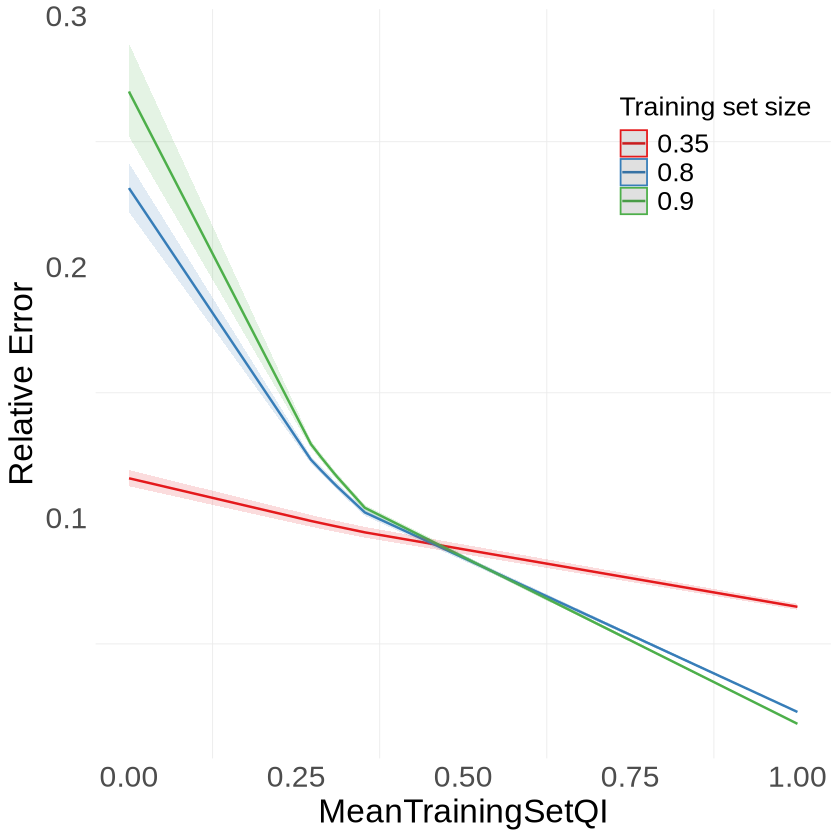

In [43]:
eff1 <- ggpredict(modelA_2, terms = c("qi_train", "train_size [0.35, 0.8, 0.9]"))
cha1 <- plot(eff1) +
  labs(
    title = NULL,  
    x = "MeanTrainingSetQI",
    y = "Relative Error",
    color = "Training set size"
  ) +
  theme_minimal() +
  theme(
    legend.position = "inside",  # Coordinates
    legend.position.inside = c(0.7, 0.9),  
    legend.justification = c("left", "top"),
    axis.title = element_text(size = 20),
    axis.text = element_text(size = 18),
    legend.text = element_text(size = 16),
    legend.title = element_text(size = 16),
    panel.grid.major = element_blank(), 
    # panel.grid.minor = element_blank()
  )

cha1
ggsave(
  "output/mape_qi_train_x_train_size_effect.png",
  cha1,
  width = 12,
  height = 6,
  dpi = 600,
)

#### QI

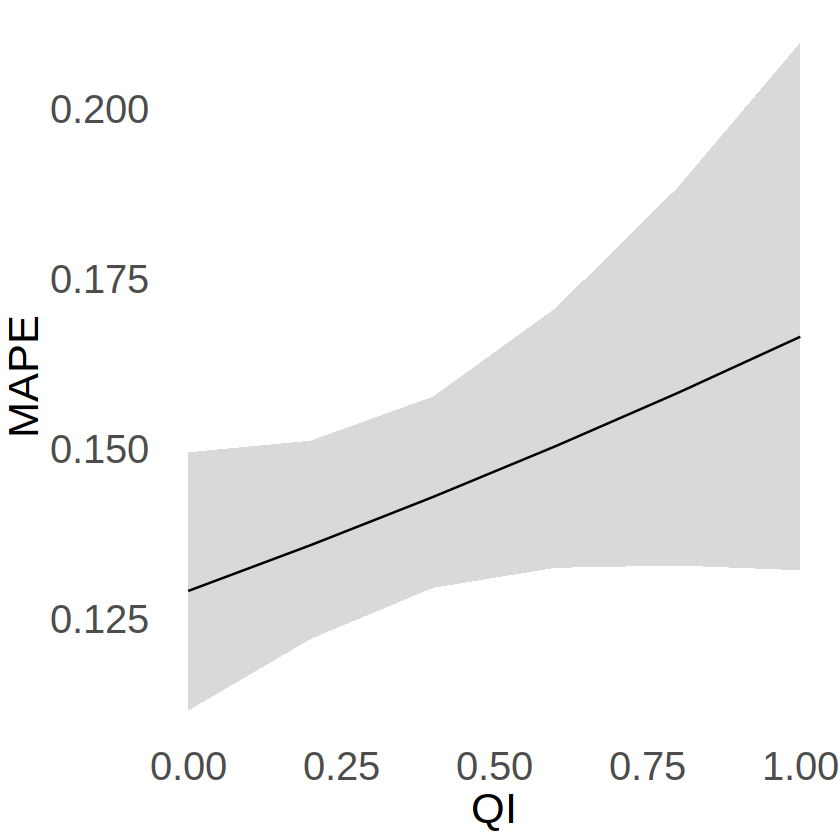

In [58]:
eff1 <- ggpredict(modelA_2, terms = c("qi"))
cha1 <- plot(eff1) +
  labs(
    title = NULL,  
    x = "QI",
    y = "MAPE",
    color = "Training set size"
  ) +
  theme_minimal() +
  theme(
    legend.position = "inside",  # Coordinates
    legend.position.inside = c(0.1, 0.9),  
    legend.justification = c("left", "top"),
    axis.title = element_text(size = 26),
    axis.text = element_text(size = 24),
    legend.text = element_text(size = 22),
    legend.title = element_text(size = 22),
    panel.grid.major = element_blank(), 
    panel.grid.minor = element_blank()
  )

cha1
ggsave(
  "output/mape_qi_effect.png",
  cha1,
  width = 12,
  height = 12,
  dpi = 600,
)

#### Weight

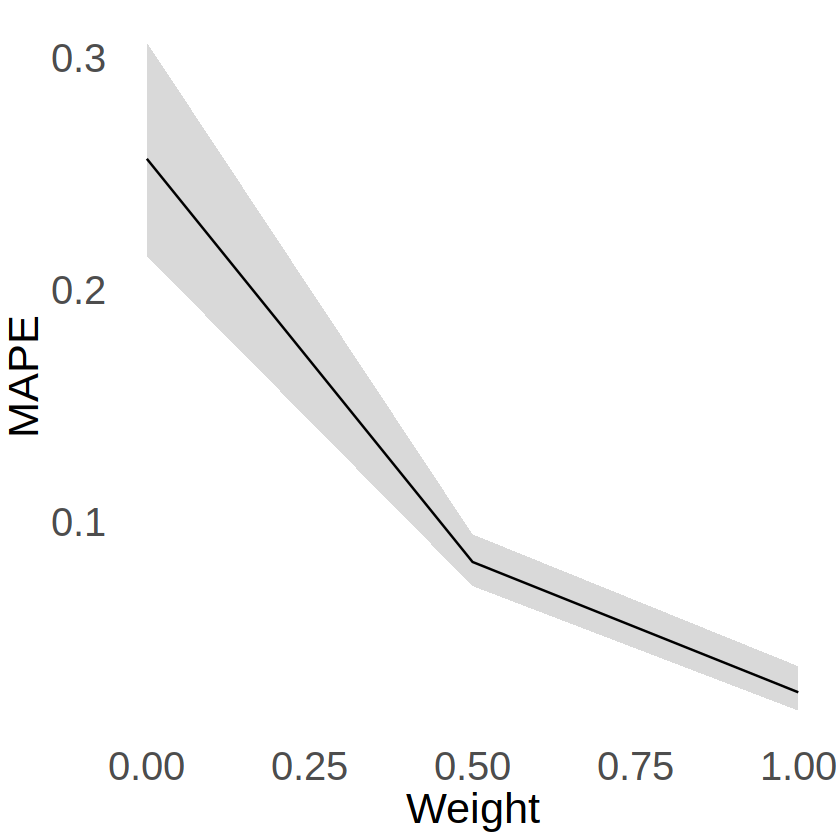

In [55]:
eff1 <- ggpredict(modelA_12, terms = c("weight"))
cha1 <- plot(eff1) +
  labs(
    title = NULL,  
    x = "Weight",
    y = "MAPE",
    color = "Training set size"
  ) +
  theme_minimal() +
  theme(
    legend.position = "inside",  # Coordinates
    legend.position.inside = c(0.6, 0.9),  
    legend.justification = c("left", "top"),
    axis.title = element_text(size = 26),
    axis.text = element_text(size = 24),
    legend.text = element_text(size = 22),
    legend.title = element_text(size = 22),
    panel.grid.major = element_blank(), 
    panel.grid.minor = element_blank()
  )

cha1
ggsave(
  "output/mape_wgt_effect.png",
  cha1,
  width = 12,
  height = 12,
  dpi = 600,
)

# 2. Variability Analsysis

## Data Distribution

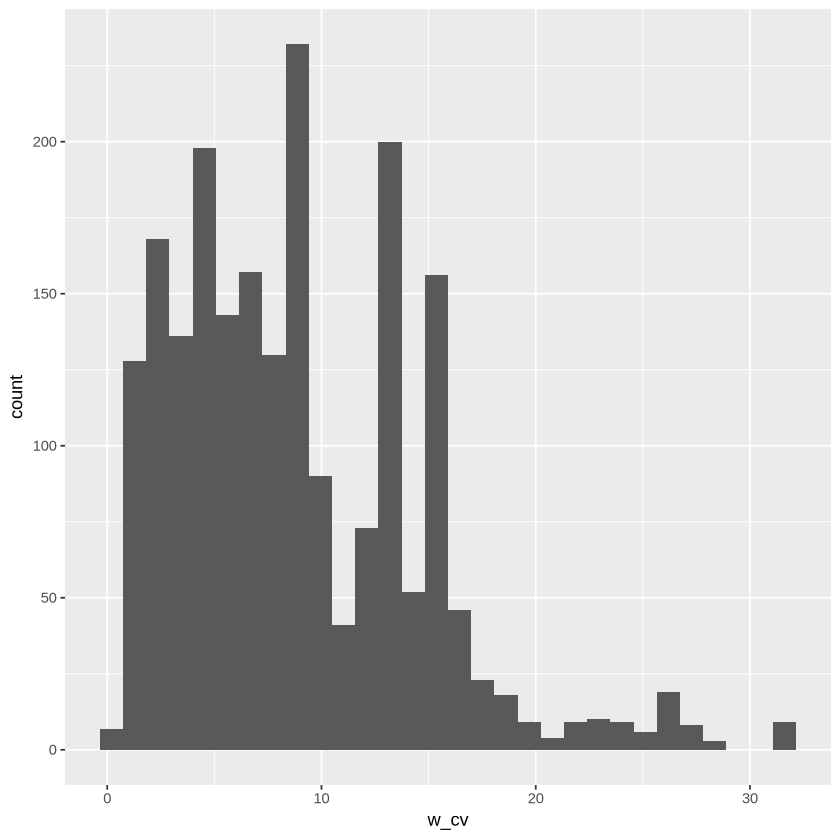

In [14]:
ggplot(dataset_v0, aes(x = w_cv)) + geom_histogram(bins = 30)

## Candidate Model #1

### Adjust Models

In [39]:
modelC_1 <- lme4::glmer(
  "w_cv ~ train_size + qi_train + qtt_in_train + qi + weight + unexpected_behavior + (1|animal_id)",
  data = dataset_v1,
  family = Gamma(link = "log")
)
summary(modelC_1)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: 
w_cv ~ train_size + qi_train + qtt_in_train + qi + weight + unexpected_behavior +  
    (1 | animal_id)
   Data: dataset_v1

      AIC       BIC    logLik -2*log(L)  df.resid 
  -4352.7   -4302.3    2185.3   -4370.7      1975 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.9979 -0.3381  0.0001  0.3343  3.3036 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.987    0.9935  
Number of obs: 1984, groups:  animal_id, 146

Fixed effects:
                        Estimate Std. Error t value Pr(>|z|)    
(Intercept)             -0.91459    0.16394  -5.579 2.42e-08 ***
train_size              -0.19409    0.07714  -2.516   0.0119 *  
qi_train                 0.60774    0.05401  11.252  < 2e-16 ***
qtt_in_train            -0.05736    0.12837  -0.447   0.6550    
qi                       0.02312    0.13221   0.175   0.86

In [40]:
# remove unexpected_behavior
modelC_2 <- lme4::glmer(
  "w_cv ~ train_size + qi_train + qtt_in_train + qi + weight + (1|animal_id)",
  data = dataset_v1,
  family = Gamma(link = "log")
)
summary(modelC_2)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size + qi_train + qtt_in_train + qi + weight + (1 |  
    animal_id)
   Data: dataset_v1

      AIC       BIC    logLik -2*log(L)  df.resid 
  -4354.5   -4309.7    2185.2   -4370.5      1976 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.9978 -0.3378 -0.0021  0.3347  3.3276 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 0.988    0.994   
Number of obs: 1984, groups:  animal_id, 146

Fixed effects:
             Estimate Std. Error t value Pr(>|z|)    
(Intercept)  -0.89208    0.15502  -5.755 8.69e-09 ***
train_size   -0.19406    0.07715  -2.515   0.0119 *  
qi_train      0.60750    0.05401  11.248  < 2e-16 ***
qtt_in_train -0.05737    0.12841  -0.447   0.6550    
qi            0.01947    0.13195   0.148   0.8827    
weight       -2.50703    0.36110  -6.943 3.85e-12 ***
---
Signif. codes:  0 ‘***’ 

In [42]:
modelC_3 <- lme4::glmer(
  "w_cv ~ train_size + qi_train + qi + weight + unexpected_behavior + (1|animal_id)",
  data = dataset_v1,
  family = Gamma(link = "log")
)
summary(modelC_3)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0766305 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting.”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size + qi_train + qi + weight + unexpected_behavior +  
    (1 | animal_id)
   Data: dataset_v1

      AIC       BIC    logLik -2*log(L)  df.resid 
  -4518.5   -4473.3    2267.2   -4534.5      2076 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.9591 -0.3238  0.0130  0.3481  3.3558 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 1.029    1.014   
Number of obs: 2084, groups:  animal_id, 151

Fixed effects:
                          Estimate Std. Error  t value Pr(>|z|)    
(Intercept)             -0.9988040  0.0009209 -1084.60   <2e-16 ***
train_size              -0.2951534  0.0009207  -320.59   <2e-16 ***
qi_train                 0.5705471  0.0009200   620.15   <2e-16 ***
qi                       0.0377605  0.0009203    41.03   <2e-16 ***
weight                  -2.1712251  0.0009205 -2358.80   <2

In [43]:
modelC_4 <- lme4::glmer(
  "w_cv ~ train_size + qi_train + qi + weight + (1|animal_id)",
  data = dataset_v1,
  family = Gamma(link = "log")
)
summary(modelC_4)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size + qi_train + qi + weight + (1 | animal_id)
   Data: dataset_v1

      AIC       BIC    logLik -2*log(L)  df.resid 
  -4520.0   -4480.5    2267.0   -4534.0      2077 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.9580 -0.3334  0.0084  0.3478  3.3364 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 1.023    1.011   
Number of obs: 2084, groups:  animal_id, 151

Fixed effects:
            Estimate Std. Error t value Pr(>|z|)    
(Intercept) -0.95988    0.14853  -6.462 1.03e-10 ***
train_size  -0.29552    0.05228  -5.653 1.58e-08 ***
qi_train     0.57143    0.05284  10.814  < 2e-16 ***
qi           0.03265    0.13260   0.246    0.805    
weight      -2.19117    0.34918  -6.275 3.49e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
           

#### 2-interactions

In [44]:
modelC_5 <- lme4::glmer(
  "w_cv ~ train_size * qi_train + qi + weight + (1|animal_id)",
  data = dataset_v1,
  family = Gamma(link = "log")
)
summary(modelC_5)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size * qi_train + qi + weight + (1 | animal_id)
   Data: dataset_v1

      AIC       BIC    logLik -2*log(L)  df.resid 
  -4683.9   -4638.7    2349.9   -4699.9      2076 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0589 -0.3705 -0.0006  0.3512  3.6571 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 1.043    1.021   
Number of obs: 2084, groups:  animal_id, 151

Fixed effects:
                    Estimate Std. Error t value Pr(>|z|)    
(Intercept)           0.6975     0.1945   3.587 0.000335 ***
train_size           -3.0974     0.2195 -14.113  < 2e-16 ***
qi_train             -1.3869     0.1573  -8.816  < 2e-16 ***
qi                    0.1397     0.1297   1.077 0.281365    
weight               -2.1422     0.3488  -6.142 8.13e-10 ***
train_size:qi_train   5.6092     0.4281  13.103  < 2e-16 ***


In [45]:
modelC_6 <- lme4::glmer(
  "w_cv ~ train_size * qi + weight + qi_train + (1|animal_id)",
  data = dataset_v1,
  family = Gamma(link = "log")
)
summary(modelC_6)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size * qi + weight + qi_train + (1 | animal_id)
   Data: dataset_v1

      AIC       BIC    logLik -2*log(L)  df.resid 
  -4713.1   -4668.0    2364.6   -4729.1      2076 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0711 -0.3150  0.0038  0.2968  3.8835 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 1.023    1.011   
Number of obs: 2084, groups:  animal_id, 151

Fixed effects:
              Estimate Std. Error t value Pr(>|z|)    
(Intercept)   -0.10594    0.15659  -0.677    0.499    
train_size    -1.42019    0.09270 -15.320  < 2e-16 ***
qi            -2.19219    0.19714 -11.120  < 2e-16 ***
weight        -2.20978    0.34119  -6.477 9.37e-11 ***
qi_train       0.88129    0.05432  16.223  < 2e-16 ***
train_size:qi  2.96493    0.20560  14.421  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.0

In [46]:
modelC_7 <- lme4::glmer(
  "w_cv ~ train_size * weight + qi_train + qi + (1|animal_id)",
  data = dataset_v1,
  family = Gamma(link = "log")
)
summary(modelC_7)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.07208 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting.”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size * weight + qi_train + qi + (1 | animal_id)
   Data: dataset_v1

      AIC       BIC    logLik -2*log(L)  df.resid 
  -4588.1   -4543.0    2302.1   -4604.1      2076 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.9802 -0.4241  0.0024  0.3950  3.2407 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 1.063    1.031   
Number of obs: 2084, groups:  animal_id, 151

Fixed effects:
                   Estimate Std. Error t value Pr(>|z|)    
(Intercept)       -0.436680   0.001008  -433.3   <2e-16 ***
train_size        -1.018003   0.001008 -1010.4   <2e-16 ***
weight            -4.074508   0.001007 -4044.7   <2e-16 ***
qi_train           0.693732   0.001040   667.3   <2e-16 ***
qi                 0.047128   0.001007    46.8   <2e-16 ***
train_size:weight  2.496235   0.001007  2478.4   <2e-16 ***
---
Sig

In [47]:
modelC_8 <- lme4::glmer(
  "w_cv ~ train_size + qi_train * qi + weight + (1|animal_id)",
  data = dataset_v1,
  family = Gamma(link = "log")
)
summary(modelC_8)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0641816 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting.”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size + qi_train * qi + weight + (1 | animal_id)
   Data: dataset_v1

      AIC       BIC    logLik -2*log(L)  df.resid 
  -4655.8   -4610.6    2335.9   -4671.8      2076 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0408 -0.3455  0.0074  0.3773  3.5462 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 1.022    1.011   
Number of obs: 2084, groups:  animal_id, 151

Fixed effects:
             Estimate Std. Error  t value Pr(>|z|)    
(Intercept) -0.884759   0.001102  -802.79   <2e-16 ***
train_size   0.076512   0.001102    69.45   <2e-16 ***
qi_train    -1.112264   0.001100 -1010.73   <2e-16 ***
qi          -0.583194   0.001101  -529.68   <2e-16 ***
weight      -2.228913   0.001101 -2023.85   <2e-16 ***
qi_train:qi  3.521030   0.001100  3199.52   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.0

In [48]:
modelC_9 <- lme4::glmer(
  "w_cv ~ train_size + qi_train * weight + qi + (1|animal_id)",
  data = dataset_v1,
  family = Gamma(link = "log")
)
summary(modelC_9)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size + qi_train * weight + qi + (1 | animal_id)
   Data: dataset_v1

      AIC       BIC    logLik -2*log(L)  df.resid 
  -4544.5   -4499.3    2280.2   -4560.5      2076 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.9646 -0.4330  0.0039  0.4567  3.2922 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 1.047    1.023   
Number of obs: 2084, groups:  animal_id, 151

Fixed effects:
                Estimate Std. Error t value Pr(>|z|)    
(Intercept)     -0.93011    0.14982  -6.208 5.36e-10 ***
train_size      -0.22109    0.05371  -4.116 3.85e-05 ***
qi_train         0.05068    0.11361   0.446    0.656    
weight          -2.44203    0.35593  -6.861 6.83e-12 ***
qi               0.03340    0.13228   0.253    0.801    
qi_train:weight  1.52803    0.29634   5.156 2.52e-07 ***
---
Signif. codes:  0 ‘***’ 

In [50]:
modelC_10 <- lme4::glmer(
  "w_cv ~ train_size + qi_train + weight * qi + (1|animal_id)",
  data = dataset_v1,
  family = Gamma(link = "log")
)
summary(modelC_10)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0781371 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting.”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size + qi_train + weight * qi + (1 | animal_id)
   Data: dataset_v1

      AIC       BIC    logLik -2*log(L)  df.resid 
  -4518.1   -4473.0    2267.1   -4534.1      2076 

Scaled residuals: 
   Min     1Q Median     3Q    Max 
-2.960 -0.331  0.010  0.359  3.346 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 1.03     1.015   
Number of obs: 2084, groups:  animal_id, 151

Fixed effects:
              Estimate Std. Error  t value Pr(>|z|)    
(Intercept) -0.9404506  0.0009033 -1041.08   <2e-16 ***
train_size  -0.2952126  0.0009031  -326.88   <2e-16 ***
qi_train     0.5707745  0.0009025   632.44   <2e-16 ***
weight      -2.2736335  0.0009029 -2518.04   <2e-16 ***
qi          -0.0233286  0.0009028   -25.84   <2e-16 ***
weight:qi    0.1989736  0.0009027   220.43   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘

#### 3-interactions

In [51]:
modelC_11 <- lme4::glmer(
  "w_cv ~ train_size * qi_train * qi + weight + (1|animal_id)",
  data = dataset_v1,
  family = Gamma(link = "log")
)
summary(modelC_11)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“unable to evaluate scaled gradient”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge: degenerate  Hessian with 1 negative eigenvalues
  See ?lme4::convergence and ?lme4::troubleshooting.”
Warning message in vcov(object, use.hessian = use.hessian):
“variance-covariance matrix computed from finite-difference Hessian is
not positive definite or contains NA values: falling back to var-cov estimated from RX”
Warning message in vcov.merMod(object, correlation = correlation, sigm = sig):
“variance-covariance matrix computed from finite-difference Hessian is
not positive definite or contains NA values: falling back to var-cov estimated from RX”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size * qi_train * qi + weight + (1 | animal_id)
   Data: dataset_v1

      AIC       BIC    logLik -2*log(L)  df.resid 
  -4741.7   -4679.6    2381.8   -4763.7      2073 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0915 -0.2742  0.0027  0.2439  3.3774 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 1.025    1.012   
Number of obs: 2084, groups:  animal_id, 151

Fixed effects:
                       Estimate Std. Error t value Pr(>|z|)    
(Intercept)              0.5717     0.1931   2.961  0.00307 ** 
train_size              -2.5507     0.3511  -7.265 3.73e-13 ***
qi_train                -1.0982     0.3641  -3.016  0.00256 ** 
qi                      -3.9680     0.7618  -5.209 1.90e-07 ***
weight                  -2.2271     0.1573 -14.160  < 2e-16 ***
train_size:qi_train      3.7383     0.8453 

In [52]:
modelC_12 <- lme4::glmer(
  "w_cv ~ train_size * qi_train * weight + qi + (1|animal_id)",
  data = dataset_v1,
  family = Gamma(link = "log")
)
summary(modelC_12)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.232946 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting.”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size * qi_train * weight + qi + (1 | animal_id)
   Data: dataset_v1

      AIC       BIC    logLik -2*log(L)  df.resid 
  -4711.4   -4649.4    2366.7   -4733.4      2073 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0652 -0.3590 -0.0008  0.3613  3.4297 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 1.073    1.036   
Number of obs: 2084, groups:  animal_id, 151

Fixed effects:
                           Estimate Std. Error t value Pr(>|z|)    
(Intercept)                  1.1236     0.3006   3.738 0.000185 ***
train_size                  -3.6112     0.4353  -8.296  < 2e-16 ***
qi_train                    -1.8073     0.3077  -5.874 4.25e-09 ***
weight                      -5.7936     1.2151  -4.768 1.86e-06 ***
qi                           0.1197     0.1291   0.927 0.353707    
train_size:qi_train

In [53]:
modelC_13 <- lme4::glmer(
  "w_cv ~ train_size * qi * weight + qi_train + (1|animal_id)",
  data = dataset_v1,
  family = Gamma(link = "log")
)
summary(modelC_13)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.155578 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting.”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( log )
Formula: w_cv ~ train_size * qi * weight + qi_train + (1 | animal_id)
   Data: dataset_v1

      AIC       BIC    logLik -2*log(L)  df.resid 
  -4730.5   -4668.5    2376.3   -4752.5      2073 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0820 -0.2920  0.0002  0.2960  3.5010 

Random effects:
 Groups    Name        Variance Std.Dev.
 animal_id (Intercept) 1.025    1.012   
Number of obs: 2084, groups:  animal_id, 151

Fixed effects:
                     Estimate Std. Error t value Pr(>|z|)    
(Intercept)           0.05642    0.19372   0.291    0.771    
train_size           -1.55776    0.14720 -10.582  < 2e-16 ***
qi                   -1.84869    0.34684  -5.330 9.82e-08 ***
weight               -2.78767    0.65824  -4.235 2.29e-05 ***
qi_train              0.92070    0.05478  16.809  < 2e-16 ***
train_size:qi         2.26121    0.35068   6.448 1.13e-

### Model Effect

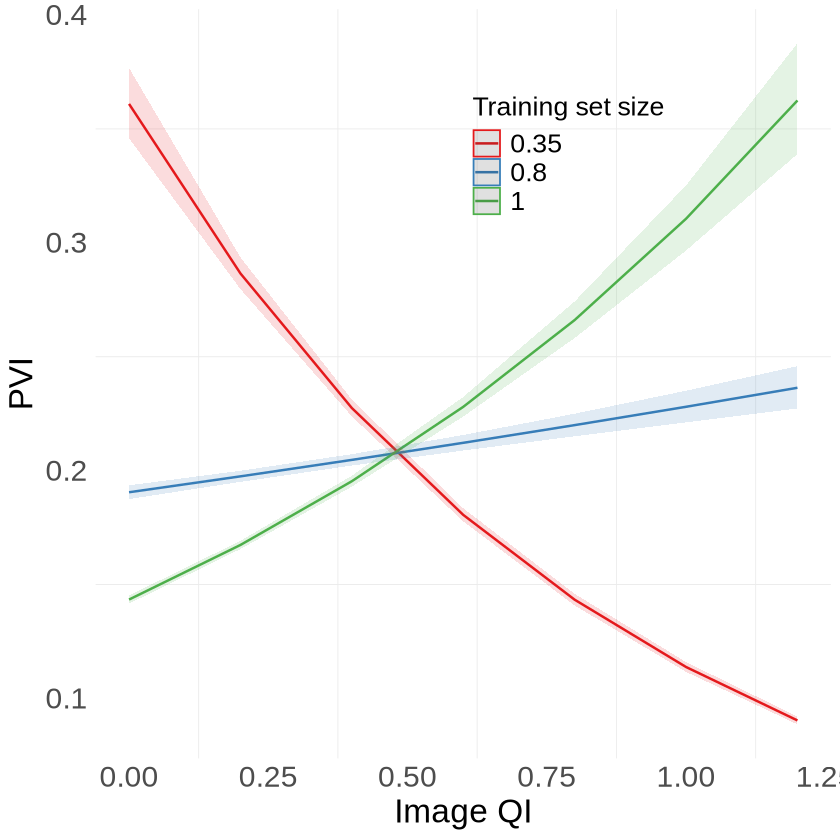

In [56]:
eff1 <- ggpredict(modelC_6, terms = c("qi", "train_size [0.35, 0.8, 1]"), bias_correction = TRUE)
cha1 <- plot(eff1) +
  labs(
    title = NULL,  
    x = "Image QI",
    y = "PVI",
    color = "Training set size"
  ) +
  theme_minimal() +
  theme(
    legend.position = "inside",  # Coordinates
    legend.position.inside = c(0.5, 0.9),  
    legend.justification = c("left", "top"),
    axis.title = element_text(size = 20),
    axis.text = element_text(size = 18),
    legend.text = element_text(size = 16),
    legend.title = element_text(size = 16),
    panel.grid.major = element_blank(), 
    # panel.grid.minor = element_blank()
  )

cha1
ggsave(
  "output/vi_qi_x_train_size_effect.png",
  cha1,
  width = 12,
  height = 5,
  dpi = 600,
)